In [1]:
import sys
import os
parent_path = os.path.abspath("E:\\SOM_trading\\som_algo_trading\\som_algo_trading")
sys.path.append(parent_path)

In [2]:
import numpy as np
import logging

from som_algo_trading import SOMTradingPipeline, TradingConfig
from som_algo_trading.utils import (
    setup_logging,
    generate_regime_prices,
    backtest_summary,
    plot_u_matrix,
    plot_cluster_signals,
    plot_equity_curve,
)

In [3]:
# ─────────────────────────────────────────────
#  Logging
# ─────────────────────────────────────────────
setup_logging(level=logging.INFO)
logger = logging.getLogger(__name__)

In [4]:
# ─────────────────────────────────────────────
#  1. Generate synthetic data
# ─────────────────────────────────────────────
N_DAYS = 1500
logger.info("Generating %d days of synthetic multi-regime prices ...", N_DAYS)
prices = generate_regime_prices(n_days=N_DAYS, random_state=42)
logger.info("Price range: %.2f – %.2f", prices.min(), prices.max())

2026-04-11 11:28:13 | INFO     | __main__ | Generating 1500 days of synthetic multi-regime prices ...
2026-04-11 11:28:13 | INFO     | __main__ | Price range: 43.71 – 131.49


In [5]:
# ─────────────────────────────────────────────
#  2. Auto-select SOM grid
# ─────────────────────────────────────────────
WINDOW_SIZE = 30
TRAIN_RATIO = 0.80

# Estimate number of training windows
n_windows_approx = int((N_DAYS - WINDOW_SIZE - 1) * TRAIN_RATIO)
#rows, cols = TradingConfig.recommend_grid(n_windows_approx)
rows, cols = 8,8
logger.info(
    "Recommended SOM grid: %dx%d (%d nodes) for ~%d windows",
    rows, cols, rows * cols, n_windows_approx,
)

2026-04-11 11:28:24 | INFO     | __main__ | Recommended SOM grid: 8x8 (64 nodes) for ~1175 windows


In [6]:
# ─────────────────────────────────────────────
#  3. Configure and train
# ─────────────────────────────────────────────
config = TradingConfig(
    window_size=WINDOW_SIZE,
    grid_rows=rows,
    grid_cols=cols,
    sigma=3.0,
    learning_rate=0.5,
    num_iterations=5_000,          # increase for production use
    anomaly_threshold=None,        # auto-calculate from 95th-pct of training QEs
    anomaly_percentile=95.0,
    min_cluster_samples=20,        # lowered for this demo dataset size
    win_rate_threshold=0.58,
    expected_return_threshold=0.0005,
    train_ratio=TRAIN_RATIO,
    random_state=42,
)
#print("\n", config, "\n")

pipeline = SOMTradingPipeline(config)
pipeline.fit(prices)

2026-04-11 11:28:42 | INFO     | som_algo_trading.pipeline | === SOMTradingPipeline.fit() START ===
2026-04-11 11:28:42 | INFO     | som_algo_trading.pipeline | Phase 1 — Data Engineering
2026-04-11 11:28:42 | INFO     | som_algo_trading.data | DataEngineer fitted | prices=1500  windows=1468  train=1174  test=294
2026-04-11 11:28:42 | INFO     | som_algo_trading.pipeline | Phase 2 — SOM Training
2026-04-11 11:28:42 | INFO     | som_algo_trading.som | Initialising SOM weights via PCA (8x8, sigma=3.00, lr=0.500) ...
2026-04-11 11:28:42 | INFO     | som_algo_trading.som | Training SOM for 5000 iterations ...
2026-04-11 11:28:42 | INFO     | som_algo_trading.som | SOM training complete.
2026-04-11 11:28:42 | INFO     | som_algo_trading.som | Cluster map built | 1174 windows → 64 / 64 nodes used
2026-04-11 11:28:42 | INFO     | som_algo_trading.inference | Anomaly threshold set to 7.9932 (95th percentile of training QEs).
2026-04-11 11:28:42 | INFO     | som_algo_trading.pipeline | === SOMT

SOMTradingPipeline(status=fitted, config=TradingConfig(
  window_size            = 30
  grid               = 8x8 (64 nodes)
  sigma                  = 3.0
  learning_rate          = 0.5
  num_iterations         = 5,000
  anomaly_threshold      = None
  anomaly_percentile     = 95.0
  min_cluster_samples    = 20
  win_rate_threshold     = 0.58
  expected_return_thresh = 0.0005
  train_ratio            = 0.8
  random_state           = 42
))

In [7]:
#  4. Walk-forward backtest
# ─────────────────────────────────────────────
logger.info("Running backtest on held-out test set ...")
bt = pipeline.backtest()
print(backtest_summary(bt))

2026-04-11 11:29:00 | INFO     | __main__ | Running backtest on held-out test set ...
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | BUY | BMU=(np.int64(7), np.int64(6)) | E[r]=0.0038 | WR=0.67 | n=21
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(4), np.int64(6)) has only 11 historical matches (minimum required: 20).
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(1), np.int64(4)) has only 11 historical matches (minimum required: 20).
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | HOLD | BMU=(np.int64(0), np.int64(6)) | E[r]=-0.0007 | WR=0.51 | n=41
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | BUY | BMU=(np.int64(7), np.int64(6)) | E[r]=0.0038 | WR=0.67 | n=21
2026-04-11 11:29:00 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(5), np.int64(2)) has only 16 historical matches (minimum required: 20).
2026-04-11 11:29:00 | INFO     | som_al

In [8]:
#  5. Live prediction
# ─────────────────────────────────────────────
# Simulate "today's" close: use the last window_size + 5 prices
live_window = prices[-(WINDOW_SIZE + 5):]
result = pipeline.predict(live_window)

print("\n=== LIVE SIGNAL ===")
print(result.summary())


2026-04-11 11:29:15 | INFO     | som_algo_trading.inference | BMU=(np.int64(1), np.int64(0)), QE=2.4045 (threshold=7.9932). Proceeding to forecast.
2026-04-11 11:29:15 | INFO     | som_algo_trading.forecaster | HOLD — Cluster (np.int64(1), np.int64(0)) has only 15 historical matches (minimum required: 20).

=== LIVE SIGNAL ===
Signal          : HOLD
BMU             : (np.int64(1), np.int64(0))
Cluster matches : 15
Reason          : Cluster (np.int64(1), np.int64(0)) has only 15 historical matches (minimum required: 20).



Generating visualisations ...


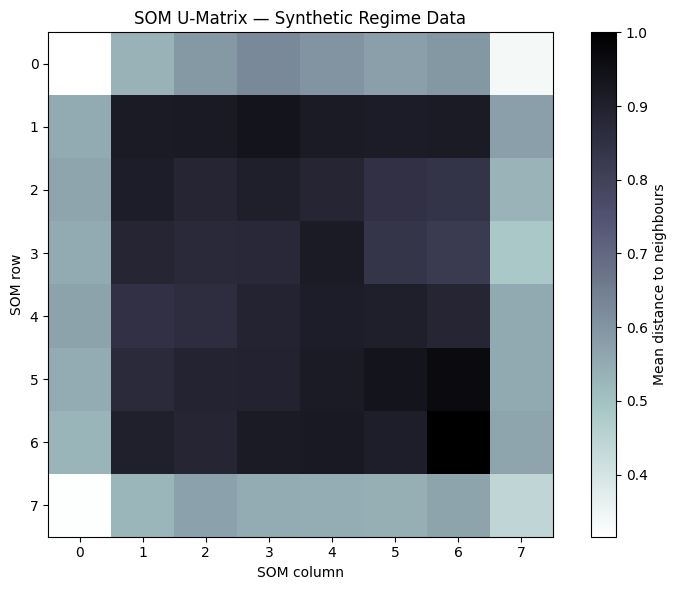

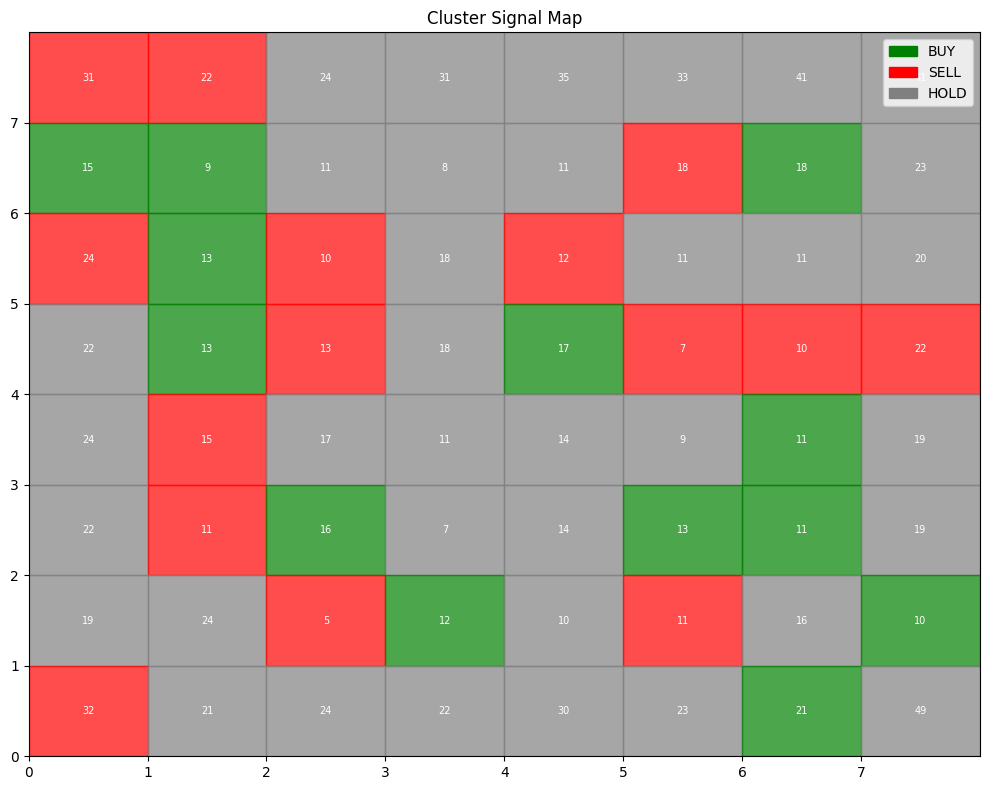

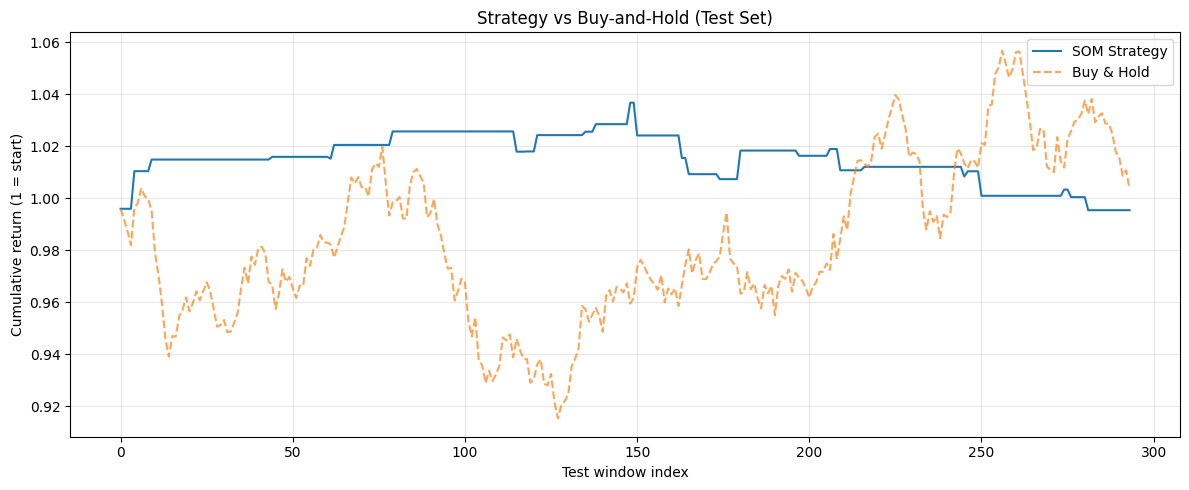

In [9]:
try:
    import matplotlib  # noqa: F401
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

if HAS_MPL:
    print("\nGenerating visualisations ...")
    plot_u_matrix(pipeline.som_core, title="SOM U-Matrix — Synthetic Regime Data")
    plot_cluster_signals(
        pipeline.forecaster,
        grid_rows=config.grid_rows,
        grid_cols=config.grid_cols,
        title="Cluster Signal Map",
    )
    plot_equity_curve(bt, title="Strategy vs Buy-and-Hold (Test Set)")
else:
    print("\nInstall matplotlib for visualisations:  pip install matplotlib")